# GAT Training and Evaluation

This notebook loads the official GAT runs from the training scripts (preferred) and plots all curves and diagnostics.
You can also switch to re-train inside the notebook if needed.
Test evaluation runs only at the end (no per-epoch test leakage).

In [23]:
from pathlib import Path
import json
import time
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.data import Data, Batch
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Resolve repo root
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    if (ROOT.parent / "data").exists():
        ROOT = ROOT.parent
    elif (ROOT.parent.parent / "data").exists():
        ROOT = ROOT.parent.parent

# Ensure repo root is on sys.path for local imports
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET_DIR = ROOT / "data" / "processed" / "gat_dataset"
LOG_DIR = ROOT / "logs" / "gat_notebook"
CKPT_DIR = ROOT / "checkpoints" / "gat_notebook"
SCRIPT_LOG_DIR = ROOT / "logs" / "gat"
SCRIPT_CKPT_DIR = ROOT / "checkpoints" / "gat"
LOG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT)
print("Dataset:", DATASET_DIR)
print("Device:", device)

ROOT: f:\footagent
Dataset: f:\footagent\data\processed\gat_dataset
Device: cpu


In [24]:
def load_split(split_name):
    path = DATASET_DIR / f"{split_name}.pt"
    if not path.exists():
        raise FileNotFoundError(f"Missing split: {path}")
    raw = torch.load(path, weights_only=False)
    data_list = []
    for g in raw:
        data_list.append(Data(x=g["x"], edge_index=g["edge_index"], y=g["y"]))
    return data_list


def create_batches(data_list, batch_size, shuffle=True):
    if shuffle:
        indices = torch.randperm(len(data_list)).tolist()
    else:
        indices = list(range(len(data_list)))

    batches = []
    for i in range(0, len(indices), batch_size):
        batch = Batch.from_data_list([data_list[j] for j in indices[i:i + batch_size]])
        batches.append(batch)

    return batches


def train_epoch(model, data_list, optimizer, criterion, batch_size):
    model.train()
    total_loss = 0.0

    batches = create_batches(data_list, batch_size, shuffle=True)
    for batch in batches:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(pred, batch.y.squeeze())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(batches), 1)


@torch.no_grad()
def evaluate(model, data_list, criterion, batch_size, return_preds=False):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    batches = create_batches(data_list, batch_size, shuffle=False)
    for batch in batches:
        batch = batch.to(device)
        pred = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(pred, batch.y.squeeze())

        total_loss += loss.item()
        all_preds.extend(pred.detach().cpu().numpy().tolist())
        all_labels.extend(batch.y.squeeze().cpu().numpy().tolist())

    preds = np.array(all_preds)
    labels = np.array(all_labels)
    mae = np.mean(np.abs(preds - labels))
    mse = np.mean((preds - labels) ** 2)
    spearman_r, spearman_p = spearmanr(preds, labels)

    metrics = {
        "loss": total_loss / max(len(batches), 1),
        "mae": float(mae),
        "mse": float(mse),
        "rmse": float(np.sqrt(mse)),
        "spearman_r": float(spearman_r),
        "spearman_p": float(spearman_p),
    }
    if return_preds:
        metrics["preds"] = preds
        metrics["labels"] = labels
    return metrics


train_data = load_split("train")
val_data = load_split("val")
test_data = load_split("test")
print(f"Train: {len(train_data)} graphs")
print(f"Val:   {len(val_data)} graphs")
print(f"Test:  {len(test_data)} graphs")

Train: 5585 graphs
Val:   1656 graphs
Test:  889 graphs


In [25]:
from models.gat.temporal_gat import get_model


def find_latest_runs(base_dir):
    runs = {}
    if not base_dir.exists():
        return runs

    for res_path in base_dir.glob("*/results.json"):
        try:
            data = json.loads(res_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        model = data.get("model")
        if not model:
            continue
        mtime = res_path.stat().st_mtime
        current = runs.get(model)
        if current is None or mtime > current["mtime"]:
            runs[model] = {
                "run_dir": res_path.parent,
                "mtime": mtime,
                "results": data,
            }
    return runs


def load_history(log_dir):
    csv_path = log_dir / "training_log.csv"
    if not csv_path.exists():
        return pd.DataFrame()
    return pd.read_csv(csv_path)


def eval_run(run_dir, model_name, batch_size):
    ckpt_path = run_dir / "best_model.pt"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")

    model = get_model(model_name).to(device)
    ckpt = torch.load(ckpt_path, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    criterion = nn.MSELoss()
    return evaluate(model, test_data, criterion, batch_size, return_preds=True)


def train_model(model_name, epochs=100, batch_size=64, lr=1e-3, weight_decay=1e-4,
                dropout=0.3, patience=15, eval_test_each_epoch=False, verbose=True):
    model = get_model(model_name, dropout=dropout).to(device)
    criterion = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)

    history = []
    best_val_loss = float("inf")
    best_epoch = 0
    patience_counter = 0
    best_state = None

    if verbose:
        print(f"{'Epoch':>5} {'Train Loss':>11} {'Val Loss':>10} {'Val MAE':>9} "
              f"{'Val RMSE':>10} {'Val Spr':>8} {'LR':>10}")
        print("-" * 78)

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss = train_epoch(model, train_data, optimizer, criterion, batch_size)
        val_metrics = evaluate(model, val_data, criterion, batch_size)
        scheduler.step()
        elapsed = time.time() - t0

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_mae": val_metrics["mae"],
            "val_rmse": val_metrics["rmse"],
            "val_spearman_r": val_metrics["spearman_r"],
            "lr": scheduler.get_last_lr()[0],
            "time_sec": elapsed,
        })

        if verbose:
            print(f"{epoch:5d} {train_loss:11.6f} {val_metrics['loss']:10.6f} "
                  f"{val_metrics['mae']:9.5f} {val_metrics['rmse']:10.5f} "
                  f"{val_metrics['spearman_r']:8.4f} {scheduler.get_last_lr()[0]:10.2e}")

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            patience_counter = 0
            best_state = {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_metrics": val_metrics,
            }
        else:
            patience_counter += 1

        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (patience={patience})")
            break

    if best_state is not None:
        model.load_state_dict(best_state["model_state_dict"])

    test_metrics = evaluate(model, test_data, criterion, batch_size, return_preds=True)

    run_name = f"nb_{model_name}_{time.strftime('%Y%m%d_%H%M%S')}"
    run_dir = CKPT_DIR / run_name
    log_dir = LOG_DIR / run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(log_dir / "training_log.csv", index=False)

    results = {
        "model": model_name,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "test_metrics": {k: float(v) for k, v in test_metrics.items() if k not in ["preds", "labels"]},
        "run_name": run_name,
        "eval_test_each_epoch": eval_test_each_epoch,
    }
    with open(run_dir / "results.json", "w") as f:
        json.dump(results, f, indent=2)

    torch.save({
        "model_state_dict": model.state_dict(),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "test_metrics": {k: float(v) for k, v in test_metrics.items() if k not in ["preds", "labels"]},
    }, run_dir / "best_model.pt")

    return hist_df, test_metrics, run_dir, results


USE_SCRIPT_RUNS = False

config = {
    "epochs": 100,
    "batch_size": 64,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "patience": 15,
    "eval_test_each_epoch": False,
    "verbose": True,
}

models = ["temporal_gat", "gat_m", "gcn"]

histories = {}
test_results = {}
run_dirs = {}
run_meta = {}

if USE_SCRIPT_RUNS:
    runs = find_latest_runs(SCRIPT_CKPT_DIR)
    if not runs:
        raise RuntimeError(f"No script runs found under {SCRIPT_CKPT_DIR}")

    for name in models:
        if name not in runs:
            raise RuntimeError(f"Missing script run for {name}")

    for name in models:
        run_dir = runs[name]["run_dir"]
        log_dir = SCRIPT_LOG_DIR / run_dir.name
        histories[name] = load_history(log_dir)
        test_results[name] = eval_run(run_dir, name, config["batch_size"])
        run_dirs[name] = run_dir
        run_meta[name] = runs[name]["results"]
        print(f"Loaded {name} from {run_dir.name} | Spearman r = {test_results[name]['spearman_r']:.4f}")
else:
    for name in models:
        print(f"Training {name} ...")
        hist_df, test_metrics, run_dir, results = train_model(name, **config)
        histories[name] = hist_df
        test_results[name] = test_metrics
        run_dirs[name] = run_dir
        run_meta[name] = results
        print(f"Done: {name} | Spearman r = {test_metrics['spearman_r']:.4f}")

Training temporal_gat ...
Epoch  Train Loss   Val Loss   Val MAE   Val RMSE  Val Spr         LR
------------------------------------------------------------------------------
    1    0.048694   0.020216   0.07142    0.14239   0.5826   1.00e-03
    2    0.019090   0.022803   0.07734    0.15120   0.6156   9.99e-04
    3    0.017507   0.021112   0.07494    0.14548   0.6619   9.98e-04
    4    0.015212   0.018351   0.06773    0.13564   0.6655   9.96e-04
    5    0.015500   0.017018   0.06503    0.13062   0.6846   9.94e-04
    6    0.014813   0.013420   0.08180    0.11592   0.6374   9.91e-04
    7    0.014451   0.018405   0.07136    0.13583   0.6990   9.88e-04
    8    0.013745   0.011783   0.05827    0.10867   0.7103   9.84e-04
    9    0.013412   0.011789   0.07384    0.10865   0.6615   9.80e-04
   10    0.013100   0.011812   0.05822    0.10879   0.7245   9.76e-04
   11    0.012030   0.011857   0.05912    0.10898   0.7415   9.71e-04
   12    0.010915   0.013190   0.06179    0.11496   0.7

# Plots and Diagnostics

The plots below show loss and Spearman r curves for each model. If per-epoch test evaluation is enabled, test curves are plotted too. Binned xG confusion matrices are included for every model (regression diagnostic).


gat_m per-epoch log
log file: f:\footagent\logs\gat_notebook\nb_gat_m_20260506_192921\training_log.csv


,epoch,train_loss,val_loss,val_mae,val_rmse,val_spearman_r,lr,time_sec
0,1,0.067654,0.028752,0.146429,0.169565,0.415967,0.001000,2.386630
1,2,0.019027,0.034673,0.162095,0.186164,0.550058,0.000999,2.368479
2,3,0.018393,0.043284,0.186097,0.207978,0.539587,0.000998,2.382081
3,4,0.017614,0.022082,0.119791,0.148601,0.500971,0.000996,2.391754
4,5,0.016726,0.043627,0.188821,0.208807,0.531721,0.000994,2.350398
5,6,0.016674,0.015629,0.080287,0.125111,0.582471,0.000991,2.359113
6,7,0.016878,0.015357,0.072272,0.124050,0.563984,0.000988,2.364645
7,8,0.016061,0.015762,0.067011,0.125678,0.558257,0.000984,2.348609
8,9,0.015743,0.020855,0.119097,0.144434,0.590009,0.000980,2.378043
9,10,0.015405,0.014047,0.071789,0.118605,0.603852,0.000976,2.393997



temporal_gat per-epoch log
log file: f:\footagent\logs\gat_notebook\nb_temporal_gat_20260506_192502\training_log.csv


,epoch,train_loss,val_loss,val_mae,val_rmse,val_spearman_r,lr,time_sec
0,1,0.048694,0.020216,0.071416,0.142388,0.582636,0.001000,5.380832
1,2,0.019090,0.022803,0.077340,0.151202,0.615632,0.000999,4.143997
2,3,0.017507,0.021112,0.074935,0.145482,0.661950,0.000998,4.241153
3,4,0.015212,0.018351,0.067735,0.135635,0.665505,0.000996,4.118922
4,5,0.015500,0.017018,0.065032,0.130623,0.684566,0.000994,4.167690
5,6,0.014813,0.013420,0.081799,0.115917,0.637423,0.000991,4.172512
6,7,0.014451,0.018405,0.071358,0.135826,0.698956,0.000988,4.162560
7,8,0.013745,0.011783,0.058271,0.108671,0.710317,0.000984,4.195815
8,9,0.013412,0.011789,0.073840,0.108646,0.661514,0.000980,4.100848
9,10,0.013100,0.011812,0.058219,0.108791,0.724456,0.000976,4.085600



gcn per-epoch log
log file: f:\footagent\logs\gat_notebook\nb_gcn_20260506_193144\training_log.csv


,epoch,train_loss,val_loss,val_mae,val_rmse,val_spearman_r,lr,time_sec
0,1,0.081544,0.020868,0.101200,0.144588,0.241134,0.001000,1.402145
1,2,0.019501,0.018642,0.083012,0.136675,0.436611,0.000999,1.332395
2,3,0.017974,0.017482,0.079730,0.132336,0.505863,0.000998,1.372873
3,4,0.017059,0.016262,0.073544,0.127641,0.504094,0.000996,1.464626
4,5,0.016414,0.016015,0.067761,0.126695,0.546877,0.000994,1.483889
5,6,0.016105,0.014892,0.074967,0.122147,0.566387,0.000991,1.372533
6,7,0.015435,0.015076,0.067481,0.122919,0.539886,0.000988,1.431860
7,8,0.014853,0.014596,0.066293,0.120944,0.561041,0.000984,1.415545
8,9,0.014846,0.016399,0.068496,0.128200,0.500614,0.000980,1.392218
9,10,0.014393,0.016806,0.067331,0.129787,0.571568,0.000976,1.468859


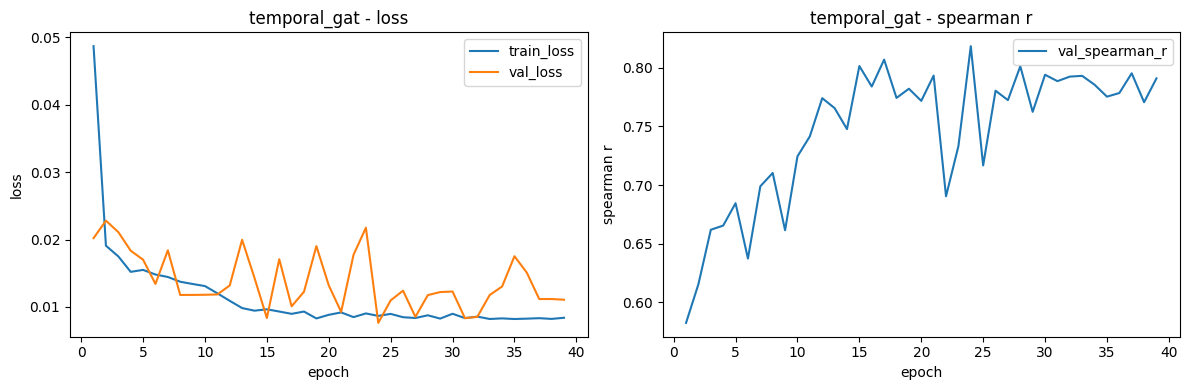

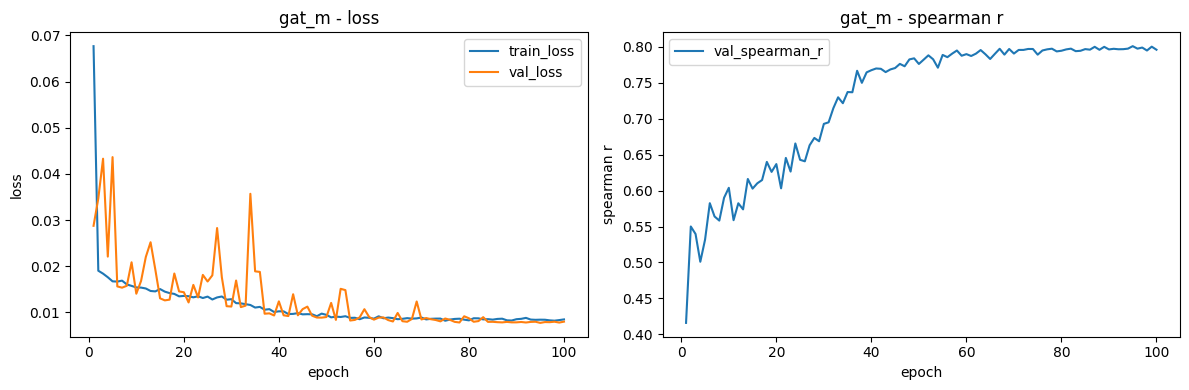

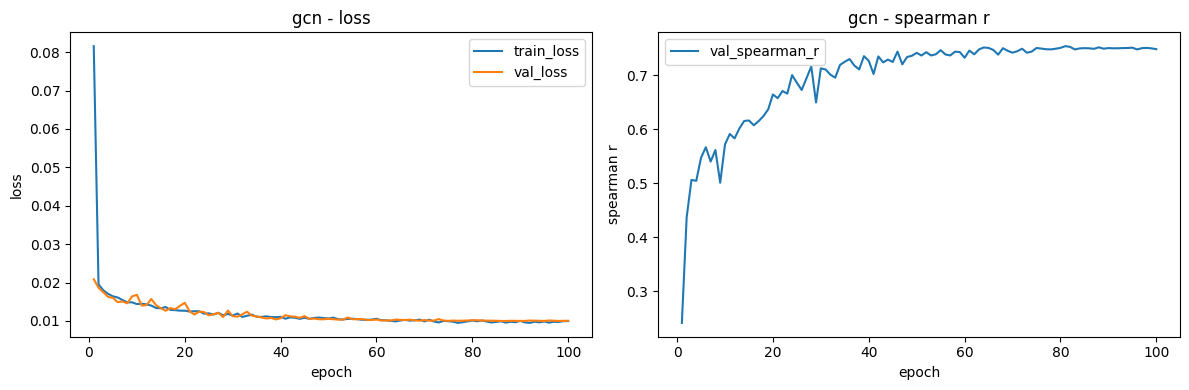

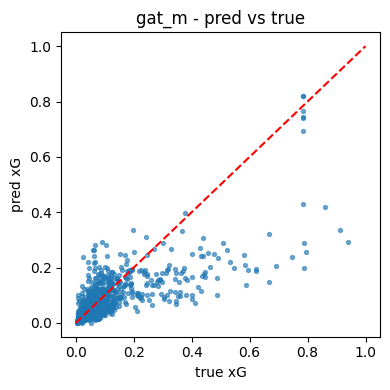

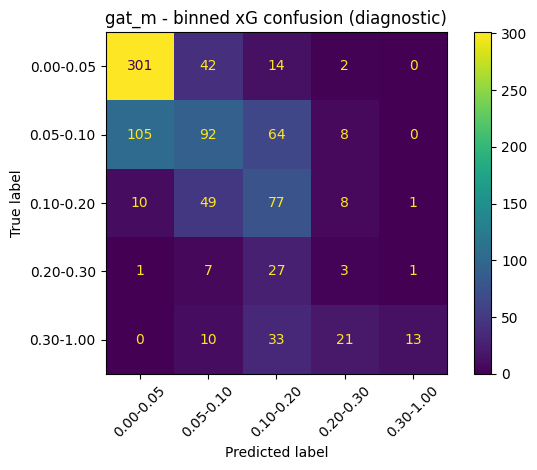

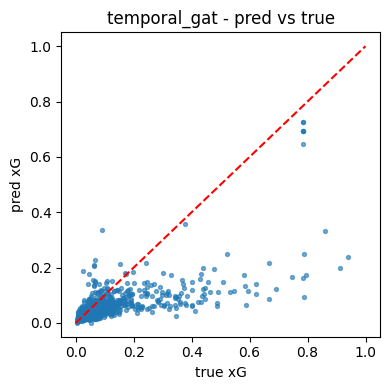

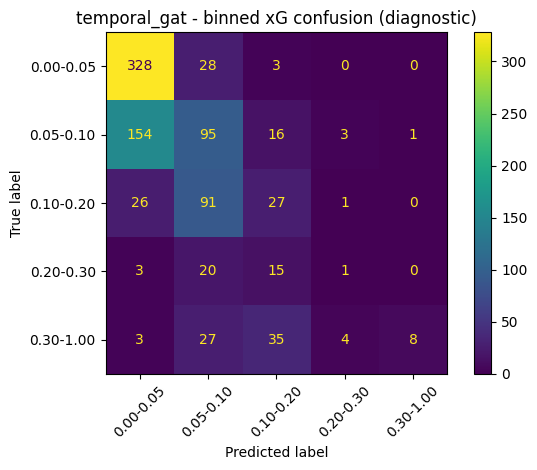

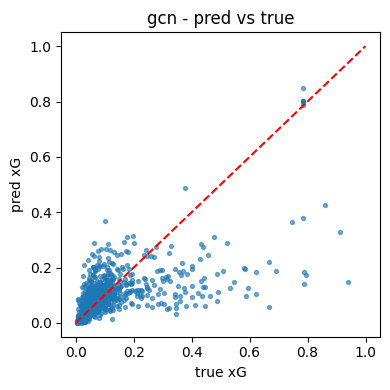

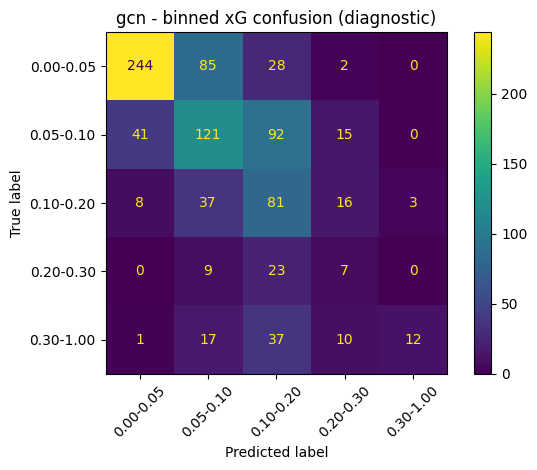

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

summary_rows = []
for name, metrics in test_results.items():
    meta = run_meta.get(name, {})
    hist = histories.get(name)
    best_epoch_log = None
    best_val_log = None
    if hist is not None and not hist.empty and "val_loss" in hist.columns:
        idx = hist["val_loss"].idxmin()
        best_epoch_log = int(hist.loc[idx, "epoch"])
        best_val_log = float(hist.loc[idx, "val_loss"])

    summary_rows.append({
        "model": name,
        "best_epoch": meta.get("best_epoch"),
        "best_val_loss": meta.get("best_val_loss"),
        "best_epoch_log": best_epoch_log,
        "best_val_log": best_val_log,
        "test_loss": metrics["loss"],
        "test_mae": metrics["mae"],
        "test_rmse": metrics["rmse"],
        "spearman_r": metrics["spearman_r"],
        "spearman_p": metrics["spearman_p"],
        "run_dir": str(run_dirs[name]),
    })
summary_df = pd.DataFrame(summary_rows).sort_values("spearman_r", ascending=False)
summary_df

PRINT_FULL_LOGS = True
if PRINT_FULL_LOGS:
    for name in summary_df["model"].tolist():
        hist = histories.get(name)
        if USE_SCRIPT_RUNS:
            log_path = SCRIPT_LOG_DIR / run_dirs[name].name / "training_log.csv"
        else:
            log_path = LOG_DIR / run_dirs[name].name / "training_log.csv"

        print(f"\n{name} per-epoch log")
        print(f"log file: {log_path}")
        if hist is None or hist.empty:
            print("(no log found)")
        else:
            display(hist)

for name, hist in histories.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["epoch"], hist["train_loss"], label="train_loss")
    axes[0].plot(hist["epoch"], hist["val_loss"], label="val_loss")
    if "test_loss" in hist.columns and hist["test_loss"].notna().any():
        axes[0].plot(hist["epoch"], hist["test_loss"], label="test_loss")
    axes[0].set_title(f"{name} - loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()

    axes[1].plot(hist["epoch"], hist["val_spearman_r"], label="val_spearman_r")
    if "test_spearman_r" in hist.columns and hist["test_spearman_r"].notna().any():
        axes[1].plot(hist["epoch"], hist["test_spearman_r"], label="test_spearman_r")
    axes[1].set_title(f"{name} - spearman r")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("spearman r")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_pred_scatter(name):
    preds = test_results[name]["preds"]
    labels = test_results[name]["labels"]
    plt.figure(figsize=(4, 4))
    plt.scatter(labels, preds, s=8, alpha=0.6)
    plt.plot([0, 1], [0, 1], "r--")
    plt.title(f"{name} - pred vs true")
    plt.xlabel("true xG")
    plt.ylabel("pred xG")
    plt.tight_layout()
    plt.show()


def plot_binned_confusion(name, bins):
    preds = test_results[name]["preds"]
    labels = test_results[name]["labels"]
    bin_edges = np.array(bins)
    pred_bins = np.digitize(preds, bin_edges, right=False) - 1
    label_bins = np.digitize(labels, bin_edges, right=False) - 1

    n_bins = len(bin_edges) - 1
    cm = confusion_matrix(label_bins, pred_bins, labels=list(range(n_bins)))
    labels_txt = [f"{bin_edges[i]:.2f}-{bin_edges[i + 1]:.2f}" for i in range(n_bins)]
    disp = ConfusionMatrixDisplay(cm, display_labels=labels_txt)
    disp.plot(xticks_rotation=45)
    plt.title(f"{name} - binned xG confusion (diagnostic)")
    plt.tight_layout()
    plt.show()


bins = [0.0, 0.05, 0.10, 0.20, 0.30, 1.00]
for name in summary_df["model"].tolist():
    plot_pred_scatter(name)
    plot_binned_confusion(name, bins)